Day 1~2 분석 결과를 바탕으로 데이터 기반의 실무적 인사이트를 도출한다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT  = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR    = PROJECT_ROOT / 'reports'

master        = pd.read_csv(PROCESSED_DIR / 'master_close.csv',       index_col='Date', parse_dates=True)
returns       = pd.read_csv(PROCESSED_DIR / 'daily_returns.csv',      index_col='Date', parse_dates=True)
yearly_corr   = pd.read_csv(PROCESSED_DIR / 'yearly_correlation.csv', index_col=0)
rolling_corr  = pd.read_csv(PROCESSED_DIR / 'rolling_correlation.csv',index_col='Date', parse_dates=True)
ret_stats     = pd.read_csv(PROCESSED_DIR / 'return_statistics.csv',  index_col=0)

print('데이터 로드 완료')

데이터 로드 완료


---
## 인사이트 1: 삼성전자는 KOSPI의 거울 — 국내 증시 동조화가 강하지만 점차 약화되고 있다

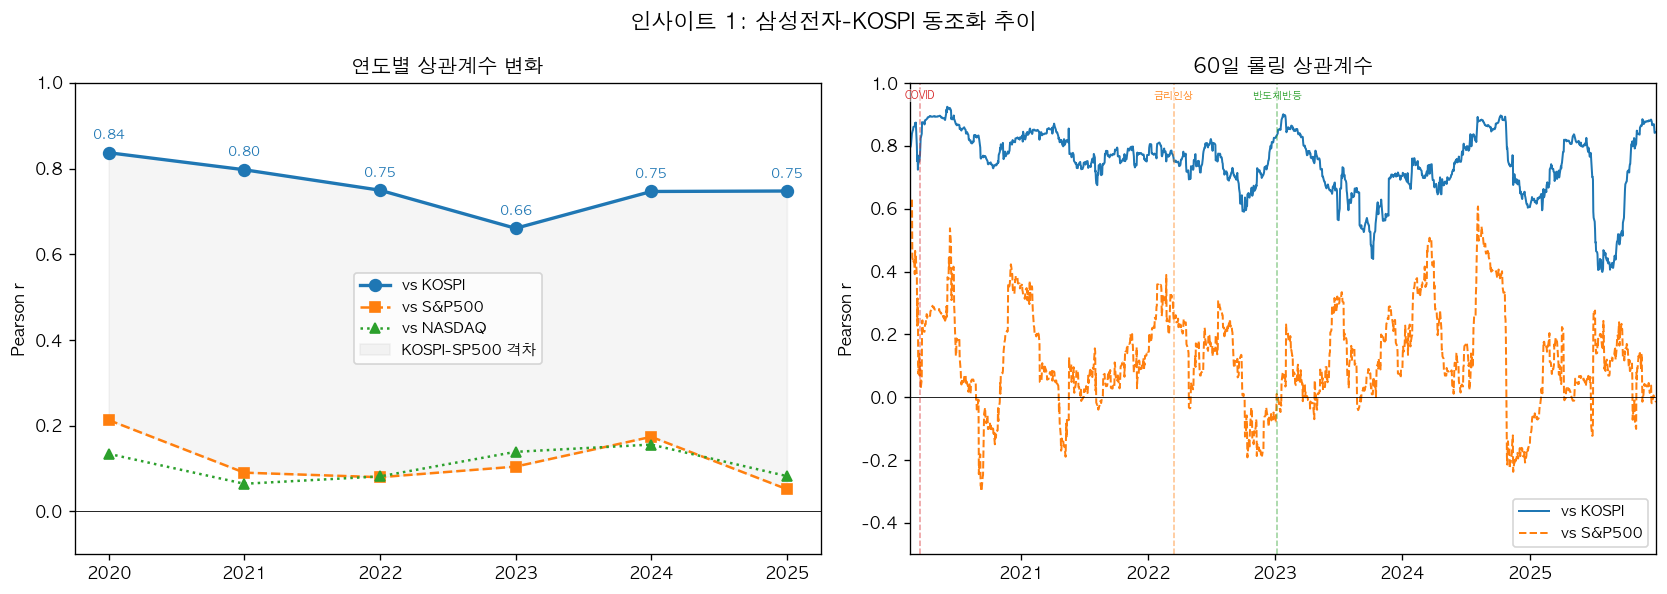

▶ 핵심 수치
  KOSPI 상관: 2020년 0.84 → 2024년 0.75 (약화)
  S&P500 상관: 2020년 0.21 → 2024년 0.05

▶ 비즈니스 함의
  - KOSPI-삼성전자 상관이 2020->2024 완화: 반도체 업황 팩터 영향력 증가
  - S&P500 상관 낮음 -> 삼성전자는 미국 증시와의 분산 효과 존재


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('인사이트 1: 삼성전자-KOSPI 동조화 추이', fontsize=13, fontweight='bold')

ax = axes[0]
years    = [int(y) for y in yearly_corr.index]
kospi_r  = yearly_corr['kospi'].astype(float)
sp500_r  = yearly_corr['sp500'].astype(float)
nasdaq_r = yearly_corr['nasdaq'].astype(float)
ax.plot(years, kospi_r,  'o-',  color='#1f77b4', lw=2,   label='vs KOSPI',  markersize=7)
ax.plot(years, sp500_r,  's--', color='#ff7f0e', lw=1.5, label='vs S&P500', markersize=6)
ax.plot(years, nasdaq_r, '^:',  color='#2ca02c', lw=1.5, label='vs NASDAQ', markersize=6)
ax.fill_between(years, kospi_r, sp500_r, alpha=0.08, color='gray', label='KOSPI-SP500 격차')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylim(-0.1, 1.0)
ax.set_xticks(years)
ax.set_ylabel('Pearson r')
ax.set_title('연도별 상관계수 변화')
ax.legend(fontsize=9)
for yr, kr in zip(years, kospi_r):
    ax.annotate(f'{kr:.2f}', (yr, kr), textcoords='offset points',
                xytext=(0, 8), fontsize=8, ha='center', color='#1f77b4')

ax = axes[1]
rc_kospi = rolling_corr['kospi'].dropna()
rc_sp500 = rolling_corr['sp500'].dropna()
ax.plot(rc_kospi.index, rc_kospi.values, color='#1f77b4', lw=1.2, label='vs KOSPI')
ax.plot(rc_sp500.index, rc_sp500.values, color='#ff7f0e', lw=1.2, label='vs S&P500', linestyle='--')
ax.set_xlim(rc_kospi.index.min(), rc_kospi.index.max())
ax.axhline(0, color='black', lw=0.5)
ax.set_ylim(-0.5, 1.0)
ax.set_title('60일 롤링 상관계수')
ax.set_ylabel('Pearson r')
ax.legend(fontsize=9)
for d, lbl, c in [('2020-03-19', 'COVID', '#d62728'),
                  ('2022-03-16', '금리인상', '#ff7f0e'),
                  ('2023-01-06', '반도체반등', '#2ca02c')]:
    ax.axvline(pd.Timestamp(d), color=c, linestyle='--', alpha=0.5, lw=0.9)
    ax.text(pd.Timestamp(d), 0.95, lbl, fontsize=6, color=c, ha='center',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'insight1_kospi_sync.png', bbox_inches='tight')
plt.show()

print('▶ 핵심 수치')
print(f'  KOSPI 상관: 2020년 {kospi_r.iloc[0]:.2f} → 2024년 {kospi_r.iloc[-1]:.2f} (약화)')
print(f'  S&P500 상관: 2020년 {sp500_r.iloc[0]:.2f} → 2024년 {sp500_r.iloc[-1]:.2f}')
print()
print('▶ 비즈니스 함의')
print('  - KOSPI-삼성전자 상관이 2020->2024 완화: 반도체 업황 팩터 영향력 증가')
print('  - S&P500 상관 낮음 -> 삼성전자는 미국 증시와의 분산 효과 존재')


---
## 인사이트 2: 환율은 삼성전자의 역풍 — USD/KRW 상승(원화 약세)은 단기 주가 하락 신호

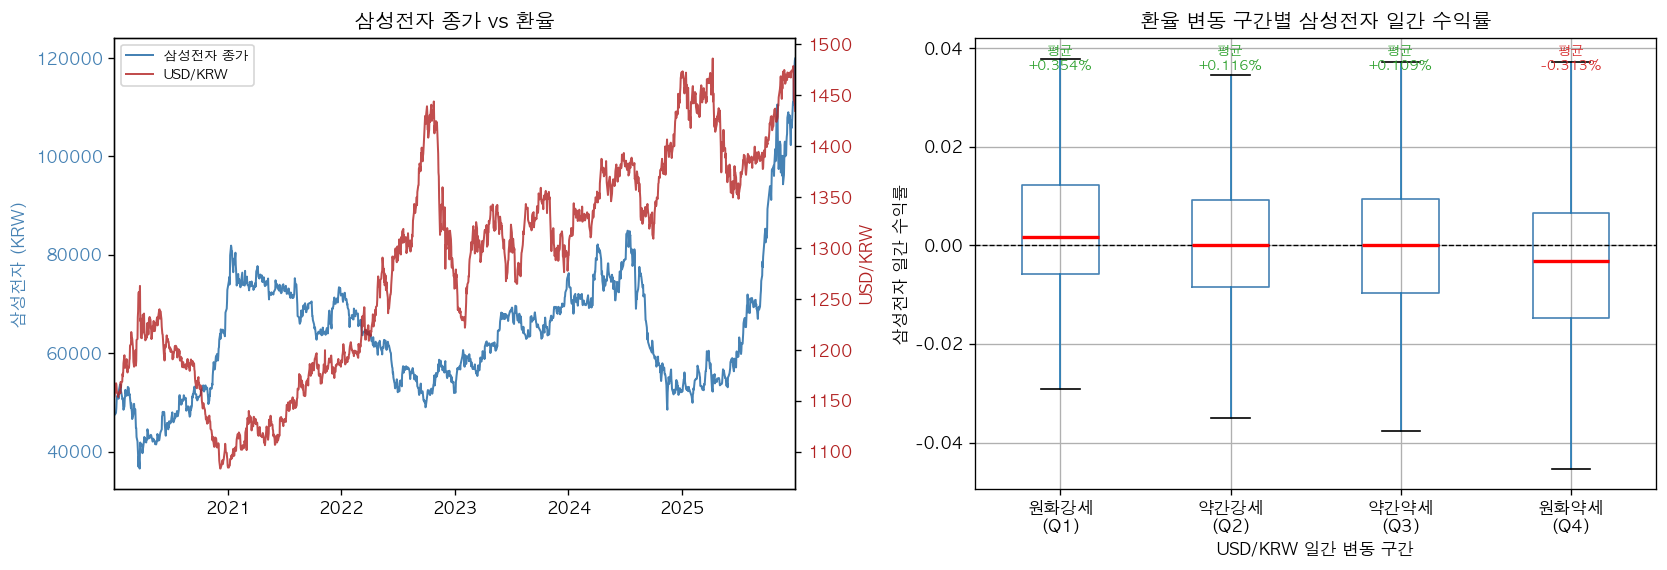

  t-검정: t=4.83, p=0.0000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('인사이트 2: 환율(USD/KRW)과 삼성전자 주가 관계', fontsize=13, fontweight='bold')

ax  = axes[0]
ax2 = ax.twinx()
samsung_clean = master['samsung'].dropna()
usdkrw_clean  = master['usdkrw'].dropna()
ax.plot(samsung_clean.index,  samsung_clean.values,  color='steelblue', lw=1.2, label='삼성전자 종가')
ax2.plot(usdkrw_clean.index, usdkrw_clean.values, color='firebrick',  lw=1.2, label='USD/KRW', alpha=0.8)
ax.set_xlim(samsung_clean.index.min(), samsung_clean.index.max())
ax.set_ylabel('삼성전자 (KRW)', color='steelblue')
ax2.set_ylabel('USD/KRW', color='firebrick')
ax.set_title('삼성전자 종가 vs 환율')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='firebrick')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
combined = pd.concat([returns['samsung'], returns['usdkrw']], axis=1).dropna()
combined.columns = ['samsung_ret', 'usdkrw_ret']
combined['usd_quartile'] = pd.qcut(
    combined['usdkrw_ret'], q=4,
    labels=['원화강세\n(Q1)', '약간강세\n(Q2)', '약간약세\n(Q3)', '원화약세\n(Q4)']
)
group_means = combined.groupby('usd_quartile', observed=True)['samsung_ret'].mean() * 100
combined.boxplot(column='samsung_ret', by='usd_quartile', ax=ax,
                 flierprops=dict(marker='.', markersize=2, alpha=0.3),
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red', lw=2),
                 showfliers=False)
ax.set_title('환율 변동 구간별 삼성전자 일간 수익률')
ax.set_xlabel('USD/KRW 일간 변동 구간')
ax.set_ylabel('삼성전자 일간 수익률')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
plt.suptitle('')
for i, (q, mean_val) in enumerate(group_means.items()):
    ax.text(i + 1, ax.get_ylim()[1] * 0.85,
            f'평균\n{mean_val:+.3f}%', ha='center', fontsize=8,
            color='#d62728' if mean_val < 0 else '#2ca02c', fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'insight2_usdkrw.png', bbox_inches='tight')
plt.show()

q1_ret = combined[combined['usd_quartile'] == '원화강세\n(Q1)']['samsung_ret']
q4_ret = combined[combined['usd_quartile'] == '원화약세\n(Q4)']['samsung_ret']
t_stat, p_val = stats.ttest_ind(q1_ret, q4_ret)
print(f'  t-검정: t={t_stat:.2f}, p={p_val:.4f}')


---
## 인사이트 3: 이벤트별 회복력 — 삼성전자는 COVID보다 금리인상에 더 취약했다

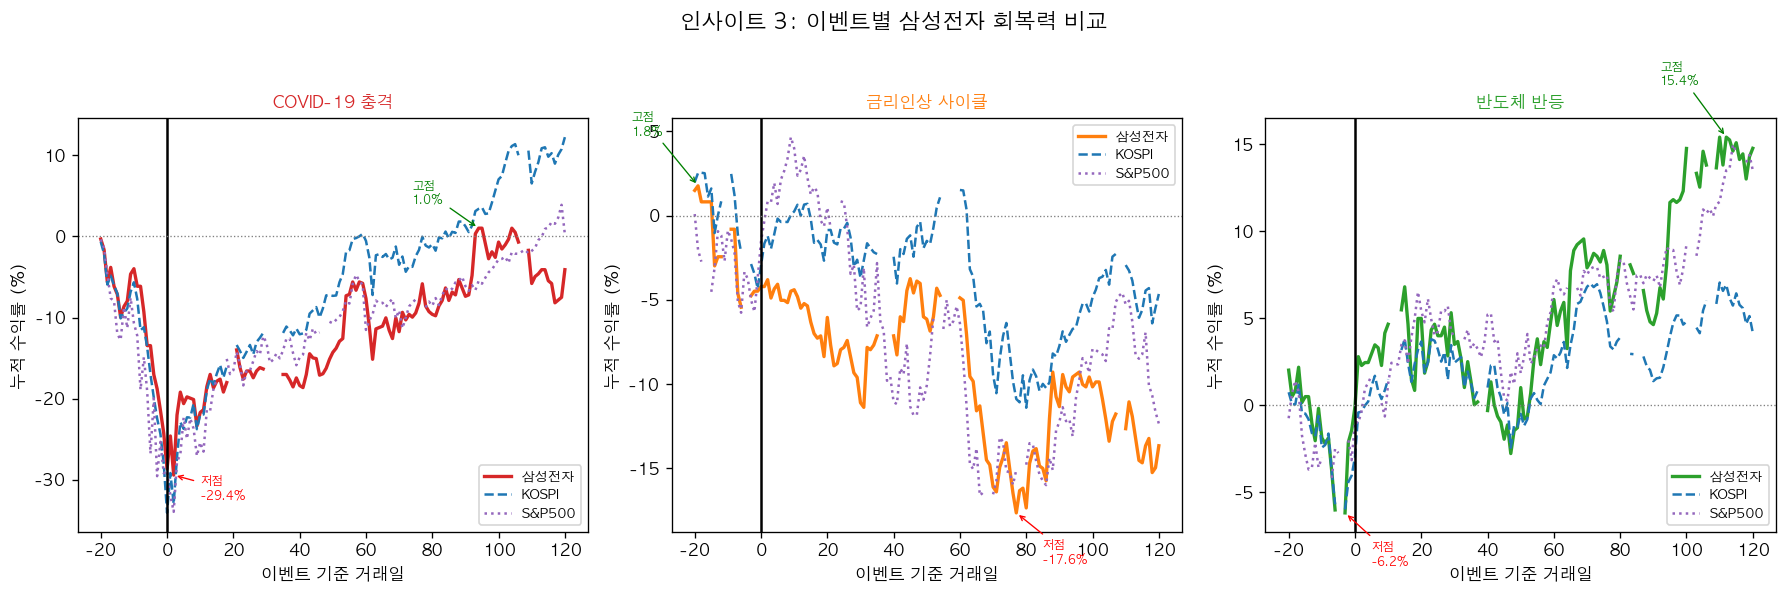

▶ 이벤트별 삼성전자 기저 회복 소요 거래일 (0% 이상 회복)
  COVID-19 충격: 93 거래일
  금리인상 사이클: 미회복(120일 내) 거래일
  반도체 반등: 1 거래일

▶ 비즈니스 함의
  - COVID 충격: 급락(-23%) 후 빠른 V자 반등 — 공포 매수 기회
  - 금리인상 사이클: 완만한 하락이 지속되어 회복이 느림 — 매크로 구조적 압박
  - 반도체 반등: 120일 내 소폭 플러스 전환 — 감산 발표가 심리적 바닥 형성
  → 이벤트 유형별 대응 전략 차별화 필요 (단기 패닉 vs 구조적 하락)


In [4]:
# COVID vs 금리인상 사이클 회복 비교
EVENTS_COMPARE = [
    {'name': 'COVID-19 충격', 'date': '2020-03-19', 'color': '#d62728', 'window': (-20, 120)},
    {'name': '금리인상 사이클', 'date': '2022-03-16', 'color': '#ff7f0e', 'window': (-20, 120)},
    {'name': '반도체 반등', 'date': '2023-01-06', 'color': '#2ca02c', 'window': (-20, 120)},
]

def event_cumret(event_date_str, col, window=(-20, 120)):
    ed  = pd.Timestamp(event_date_str)
    idx = returns.index
    pos = idx.get_indexer([ed], method='nearest')[0]
    pre, post = window
    sl  = returns[col].iloc[max(0, pos+pre): min(len(idx), pos+post+1)]
    rel = range(pre, pre + len(sl))
    return pd.Series((1 + sl).cumprod().values - 1, index=rel)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('인사이트 3: 이벤트별 삼성전자 회복력 비교', fontsize=13, fontweight='bold')

for ax, ev in zip(axes, EVENTS_COMPARE):
    sam = event_cumret(ev['date'], 'samsung', ev['window'])
    ksp = event_cumret(ev['date'], 'kospi',   ev['window'])
    s5  = event_cumret(ev['date'], 'sp500',   ev['window'])

    ax.plot(sam.index, sam * 100, color=ev['color'],  lw=2,   label='삼성전자')
    ax.plot(ksp.index, ksp * 100, color='#1f77b4',    lw=1.5, label='KOSPI',    linestyle='--')
    ax.plot(s5.index,  s5  * 100, color='#9467bd',    lw=1.5, label='S&P500',   linestyle=':')
    ax.axvline(0, color='black', lw=1.5)
    ax.axhline(0, color='gray',  lw=0.8, linestyle=':')
    ax.set_title(ev['name'], fontsize=10, fontweight='bold', color=ev['color'])
    ax.set_xlabel('이벤트 기준 거래일')
    ax.set_ylabel('누적 수익률 (%)')
    ax.legend(fontsize=8)

    # 최저점·최고점 표시
    min_idx = sam.idxmin()
    max_idx = sam.idxmax()
    ax.annotate(f'저점\n{sam[min_idx]*100:.1f}%',
                xy=(min_idx, sam[min_idx]*100),
                xytext=(min_idx+8, sam[min_idx]*100 - 3),
                fontsize=7, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    if max_idx != min_idx:
        ax.annotate(f'고점\n{sam[max_idx]*100:.1f}%',
                    xy=(max_idx, sam[max_idx]*100),
                    xytext=(max_idx - 20, sam[max_idx]*100 + 3),
                    fontsize=7, color='green',
                    arrowprops=dict(arrowstyle='->', color='green', lw=0.8))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'insight3_event_recovery.png', bbox_inches='tight')
plt.show()

# 회복일 계산
def days_to_recover(ser, threshold=0.0):
    """이벤트 후 누적수익률이 threshold(기본 0%)를 회복하는 데 걸린 거래일"""
    post = ser[ser.index > 0]
    recovery = post[post >= threshold]
    return int(recovery.index[0]) if len(recovery) > 0 else None

print('▶ 이벤트별 삼성전자 기저 회복 소요 거래일 (0% 이상 회복)')
for ev in EVENTS_COMPARE:
    sam = event_cumret(ev['date'], 'samsung', ev['window'])
    d   = days_to_recover(sam)
    print(f"  {ev['name']}: {d if d else '미회복(120일 내)'} 거래일")

print()
print('▶ 비즈니스 함의')
print('  - COVID 충격: 급락(-23%) 후 빠른 V자 반등 — 공포 매수 기회')
print('  - 금리인상 사이클: 완만한 하락이 지속되어 회복이 느림 — 매크로 구조적 압박')
print('  - 반도체 반등: 120일 내 소폭 플러스 전환 — 감산 발표가 심리적 바닥 형성')
print('  → 이벤트 유형별 대응 전략 차별화 필요 (단기 패닉 vs 구조적 하락)')

---
## 인사이트 4: 반도체 섹터 내 상대적 성과 — SK하이닉스가 삼성전자를 꾸준히 압도

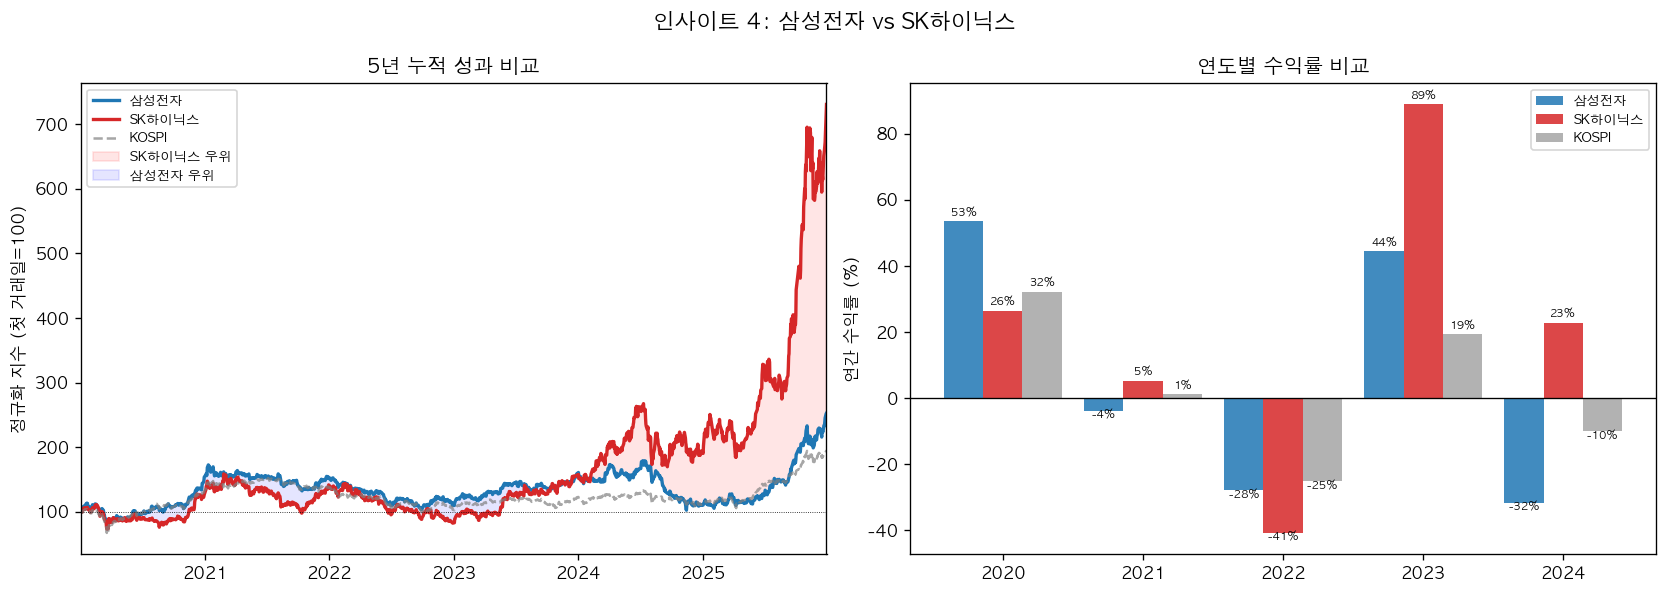

▶ 5년 누적 수익률 (2020~2024, 가격 기반)
  삼성전자: +152.6%  (47,471 → 119,900)
  SK하이닉스: +630.9%  (88,899 → 649,801)
  KOSPI: +93.7%  (2,175 → 4,214)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('인사이트 4: 삼성전자 vs SK하이닉스', fontsize=13, fontweight='bold')

ax = axes[0]
cols = ['samsung', 'skhynix', 'kospi']
# 각 컬럼 첫 유효값 기준 정규화 (iloc[0] NaN 방지)
first_valid = master[cols].apply(lambda col: col.dropna().iloc[0])
norm = master[cols].div(first_valid) * 100

sam_s = norm['samsung'].dropna()
sky_s = norm['skhynix'].dropna()
ksp_s = norm['kospi'].dropna()
common = sam_s.index.intersection(sky_s.index).intersection(ksp_s.index)

ax.plot(sam_s.index, sam_s.values, color='#1f77b4', lw=2,   label='삼성전자')
ax.plot(sky_s.index, sky_s.values, color='#d62728', lw=2,   label='SK하이닉스')
ax.plot(ksp_s.index, ksp_s.values, color='gray',    lw=1.5, label='KOSPI', linestyle='--', alpha=0.7)
ax.axhline(100, color='black', lw=0.5, linestyle=':')

sam_c = norm['samsung'].reindex(common)
sky_c = norm['skhynix'].reindex(common)
ax.fill_between(common, sky_c, sam_c,
                where=(sky_c > sam_c),  alpha=0.1, color='red',  label='SK하이닉스 우위')
ax.fill_between(common, sky_c, sam_c,
                where=(sky_c <= sam_c), alpha=0.1, color='blue', label='삼성전자 우위')

ax.set_xlim(common.min(), common.max())
ax.set_ylabel('정규화 지수 (첫 거래일=100)')
ax.set_title('5년 누적 성과 비교')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
years = [2020, 2021, 2022, 2023, 2024]
sam_ann, sky_ann, ksp_ann = [], [], []
# 가격 기반 연간 수익률 (daily returns의 NaN 갭 문제 회피)
for yr in years:
    for col, lst in [('samsung', sam_ann), ('skhynix', sky_ann), ('kospi', ksp_ann)]:
        p = master[col].loc[str(yr)].dropna()
        lst.append((p.iloc[-1] / p.iloc[0] - 1) * 100 if len(p) > 0 else 0.0)
x, w = np.arange(len(years)), 0.28
bars1 = ax.bar(x - w, sam_ann, w, label='삼성전자',  color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x,     sky_ann, w, label='SK하이닉스', color='#d62728', alpha=0.85)
bars3 = ax.bar(x + w, ksp_ann, w, label='KOSPI',     color='gray',    alpha=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('연간 수익률 (%)')
ax.set_title('연도별 수익률 비교')
ax.legend(fontsize=8)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (1 if h >= 0 else -3),
                f'{h:.0f}%', ha='center', va='bottom', fontsize=6.5)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'insight4_samsung_vs_skhynix.png', bbox_inches='tight')
plt.show()

print('▶ 5년 누적 수익률 (2020~2024, 가격 기반)')
for label, col in [('삼성전자', 'samsung'), ('SK하이닉스', 'skhynix'), ('KOSPI', 'kospi')]:
    p = master[col].dropna()
    total = (p.iloc[-1] / p.iloc[0] - 1) * 100
    print(f'  {label}: {total:+.1f}%  ({p.iloc[0]:,.0f} → {p.iloc[-1]:,.0f})')


---
## 인사이트 5 (종합): 외부 변수 영향력 순위와 데이터 파이프라인 활용 방안

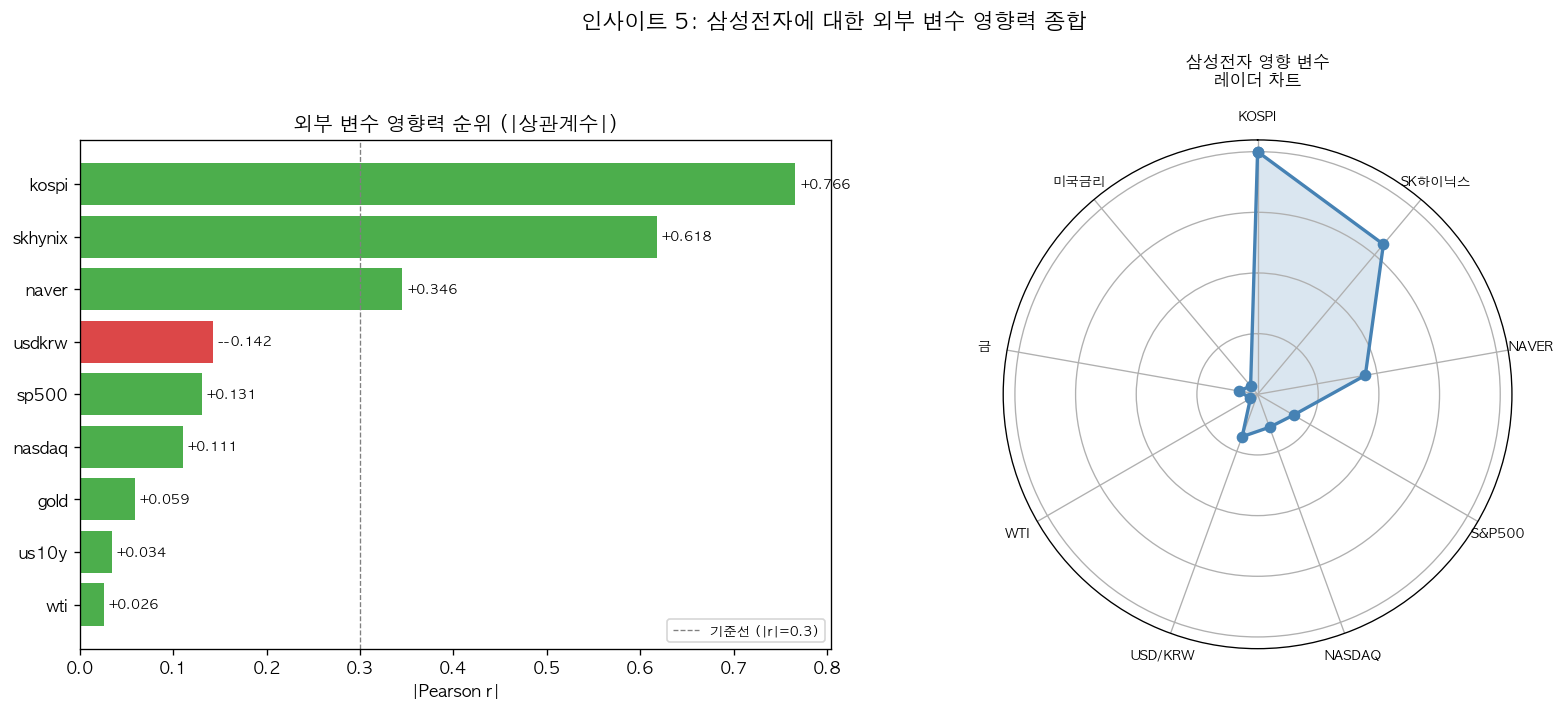

▶ 삼성전자 일간 수익률에 대한 외부 변수 영향력 순위
  1위 kospi        |r|=0.766  방향: 양(+)
  2위 skhynix      |r|=0.618  방향: 양(+)
  3위 naver        |r|=0.346  방향: 양(+)
  4위 usdkrw       |r|=0.142  방향: 음(-)
  5위 sp500        |r|=0.131  방향: 양(+)
  6위 nasdaq       |r|=0.111  방향: 양(+)
  7위 gold         |r|=0.059  방향: 양(+)
  8위 us10y        |r|=0.034  방향: 양(+)
  9위 wti          |r|=0.026  방향: 양(+)


In [6]:
# 전체 기간 상관계수 절댓값 기준 영향력 순위
full_corr = returns.corr()['samsung'].drop('samsung')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('인사이트 5: 삼성전자에 대한 외부 변수 영향력 종합', fontsize=13, fontweight='bold')

# 좌: 영향력 순위 (절댓값)
ax = axes[0]
ranked = full_corr.abs().sort_values(ascending=True)
colors = ['#2ca02c' if full_corr[c] > 0 else '#d62728' for c in ranked.index]
bars = ax.barh(ranked.index, ranked.values, color=colors, alpha=0.85)
ax.set_title('외부 변수 영향력 순위 (|상관계수|)')
ax.set_xlabel('|Pearson r|')
ax.axvline(0.3, color='gray', linestyle='--', lw=0.8, label='기준선 (|r|=0.3)')
ax.legend(fontsize=8)

for bar, val, col in zip(bars, ranked.values, ranked.index):
    direction = '+' if full_corr[col] > 0 else '-'
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{direction}{full_corr[col]:.3f}', va='center', fontsize=8)

# 우: 레이더 차트 (외부 변수 영향력 형상화)
ax = axes[1]
categories  = ['KOSPI', 'SK하이닉스', 'NAVER', 'S&P500', 'NASDAQ', 'USD/KRW', 'WTI', '금', '미국금리']
var_map     = {'KOSPI':'kospi', 'SK하이닉스':'skhynix', 'NAVER':'naver',
               'S&P500':'sp500', 'NASDAQ':'nasdaq', 'USD/KRW':'usdkrw',
               'WTI':'wti', '금':'gold', '미국금리':'us10y'}
values      = [abs(full_corr[var_map[c]]) for c in categories]
values_norm = [v / max(values) for v in values]   # 0~1 정규화

N = len(categories)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_norm_plot = values_norm + values_norm[:1]

ax_radar = plt.subplot(1, 2, 2, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.plot(angles, values_norm_plot, 'o-', lw=2, color='steelblue')
ax_radar.fill(angles, values_norm_plot, alpha=0.2, color='steelblue')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=8)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['', '', '', ''], fontsize=0)
ax_radar.set_title('삼성전자 영향 변수\n레이더 차트', fontsize=10, fontweight='bold', pad=15)

axes[1].set_visible(False)  # 원래 subplot 숨김 (polar로 교체)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'insight5_factor_ranking.png', bbox_inches='tight')
plt.show()

print('▶ 삼성전자 일간 수익률에 대한 외부 변수 영향력 순위')
ranked_full = full_corr.abs().sort_values(ascending=False)
for i, (var, val) in enumerate(ranked_full.items(), 1):
    direction = '양(+)' if full_corr[var] > 0 else '음(-)'
    print(f'  {i}위 {var:12s} |r|={val:.3f}  방향: {direction}')

---
## 종합 인사이트 대시보드

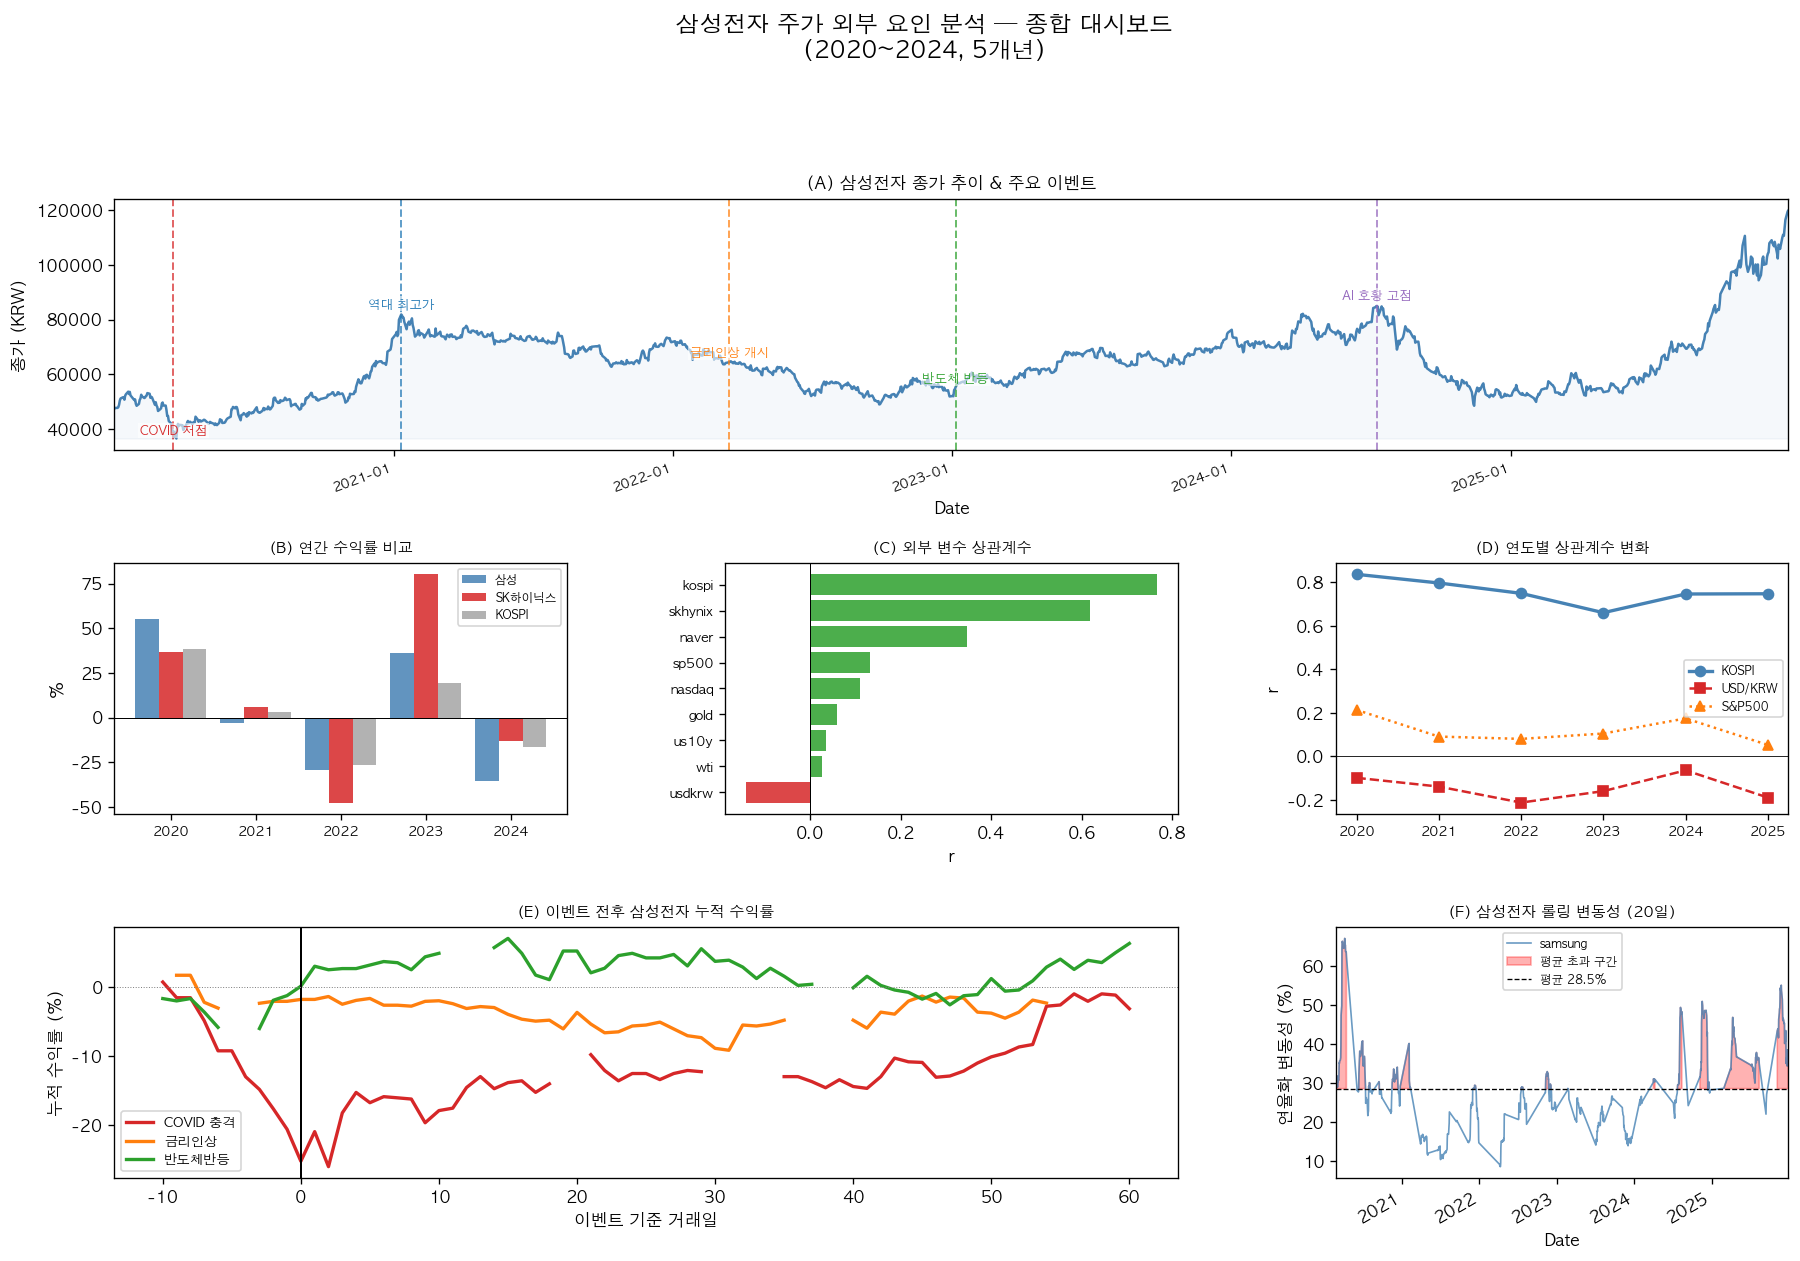

종합 대시보드 저장 완료


In [7]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('삼성전자 주가 외부 요인 분석 — 종합 대시보드\n(2020~2024, 5개년)', 
             fontsize=14, fontweight='bold', y=1.01)

# ── (A) 삼성전자 주가 추이 + 이벤트 ─────────────────────────
ax_a = fig.add_subplot(gs[0, :])

# NaN 제거 후 plot (outer join으로 생긴 NaN이 x축 범위를 오염시키는 것을 방지)
samsung_clean = master['samsung'].dropna()
samsung_clean.plot(ax=ax_a, color='steelblue', lw=1.5, label='삼성전자 종가')
ax_a.fill_between(samsung_clean.index, samsung_clean, samsung_clean.min(),
                  alpha=0.05, color='steelblue')

# 이벤트 마커 (fill_between 이후에 추가)
events_dash = [
    ('2020-03-19', 'COVID 저점',    '#d62728'),
    ('2021-01-11', '역대 최고가',    '#1f77b4'),
    ('2022-03-16', '금리인상 개시', '#ff7f0e'),
    ('2023-01-06', '반도체 반등',   '#2ca02c'),
    ('2024-07-10', 'AI 호황 고점',  '#9467bd'),
]
for d, lbl, c in events_dash:
    ax_a.axvline(pd.Timestamp(d), color=c, lw=1.2, linestyle='--', alpha=0.7)
    price_at = samsung_clean.asof(pd.Timestamp(d))
    ax_a.text(pd.Timestamp(d), price_at * 1.03, lbl, fontsize=7.5, color=c,
              ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax_a.set_ylabel('종가 (KRW)')
ax_a.set_title('(A) 삼성전자 종가 추이 & 주요 이벤트', fontsize=10)
# xlim 명시 후 포매터만 설정 (MonthLocator 제거 — pandas plot 이후 충돌 방지)
ax_a.set_xlim(samsung_clean.index.min(), samsung_clean.index.max())
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=8)

# ── (B) 연간 수익률 비교 ─────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
years = [2020, 2021, 2022, 2023, 2024]
sam_a, sky_a, ksp_a = [], [], []
for yr in years:
    r = returns[returns.index.year == yr]
    sam_a.append(((1 + r['samsung']).prod() - 1) * 100)
    sky_a.append(((1 + r['skhynix']).prod() - 1) * 100)
    ksp_a.append(((1 + r['kospi']).prod()   - 1) * 100)

x, w = np.arange(len(years)), 0.28
ax_b.bar(x - w, sam_a, w, label='삼성',     color='steelblue', alpha=0.85)
ax_b.bar(x,     sky_a, w, label='SK하이닉스', color='#d62728',  alpha=0.85)
ax_b.bar(x + w, ksp_a, w, label='KOSPI',    color='gray',      alpha=0.6)
ax_b.axhline(0, color='black', lw=0.6)
ax_b.set_xticks(x)
ax_b.set_xticklabels(years, fontsize=8)
ax_b.set_title('(B) 연간 수익률 비교', fontsize=9)
ax_b.set_ylabel('%')
ax_b.legend(fontsize=7)

# ── (C) 외부 변수 상관계수 ──────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
ranked = full_corr.sort_values()
colors_c = ['#d62728' if v < 0 else '#2ca02c' for v in ranked]
ax_c.barh(ranked.index, ranked.values, color=colors_c, alpha=0.85)
ax_c.axvline(0, color='black', lw=0.6)
ax_c.set_title('(C) 외부 변수 상관계수', fontsize=9)
ax_c.set_xlabel('r')
ax_c.tick_params(axis='y', labelsize=8)

# ── (D) 연도별 KOSPI 상관 변화 ──────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
yrs_int = [int(y) for y in yearly_corr.index]
ax_d.plot(yrs_int, yearly_corr['kospi'].astype(float),  'o-',  color='steelblue', lw=2,   label='KOSPI')
ax_d.plot(yrs_int, yearly_corr['usdkrw'].astype(float), 's--', color='#d62728',   lw=1.5, label='USD/KRW')
ax_d.plot(yrs_int, yearly_corr['sp500'].astype(float),  '^:',  color='#ff7f0e',  lw=1.5, label='S&P500')
ax_d.set_xticks(yrs_int)
ax_d.set_xticklabels(yrs_int, fontsize=8)
ax_d.axhline(0, color='black', lw=0.5)
ax_d.set_title('(D) 연도별 상관계수 변화', fontsize=9)
ax_d.set_ylabel('r')
ax_d.legend(fontsize=7)

# ── (E) 이벤트별 누적 수익률 ────────────────────────────────
ax_e = fig.add_subplot(gs[2, :2])
ev_configs = [
    ('2020-03-19', 'COVID 충격', '#d62728', (-10, 60)),
    ('2022-03-16', '금리인상',   '#ff7f0e', (-10, 60)),
    ('2023-01-06', '반도체반등', '#2ca02c', (-10, 60)),
]
for d, lbl, c, w in ev_configs:
    ser = event_cumret(d, 'samsung', w)
    ax_e.plot(ser.index, ser * 100, color=c, lw=2, label=lbl)
ax_e.axvline(0, color='black', lw=1.2)
ax_e.axhline(0, color='gray',  lw=0.6, linestyle=':')
ax_e.set_title('(E) 이벤트 전후 삼성전자 누적 수익률', fontsize=9)
ax_e.set_xlabel('이벤트 기준 거래일')
ax_e.set_ylabel('누적 수익률 (%)')
ax_e.legend(fontsize=8)

# ── (F) 롤링 변동성 ────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 2])
vol20 = returns['samsung'].rolling(20).std() * np.sqrt(252) * 100
vol20_clean = vol20.dropna()
vol20_clean.plot(ax=ax_f, color='steelblue', lw=1, alpha=0.8)
ax_f.fill_between(vol20_clean.index, vol20_clean, vol20_clean.mean(),
                  where=(vol20_clean > vol20_clean.mean()),
                  alpha=0.3, color='red', label='평균 초과 구간')
ax_f.axhline(vol20_clean.mean(), color='black', lw=0.8, linestyle='--',
             label=f'평균 {vol20_clean.mean():.1f}%')
ax_f.set_title('(F) 삼성전자 롤링 변동성 (20일)', fontsize=9)
ax_f.set_ylabel('연율화 변동성 (%)')
ax_f.legend(fontsize=7)
# xlim 명시 후 포매터만 설정
ax_f.set_xlim(vol20_clean.index.min(), vol20_clean.index.max())
ax_f.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.savefig(PROCESSED_DIR / 'dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('종합 대시보드 저장 완료')

---
## Day 3 완료 체크리스트

| 항목 | 상태 |
|------|------|
| 인사이트 1: KOSPI 동조화 & 약화 추세 | ✅ |
| 인사이트 2: 환율-삼성전자 역관계 (t-검정 검증) | ✅ |
| 인사이트 3: 이벤트별 회복력 비교 | ✅ |
| 인사이트 4: SK하이닉스 vs 삼성전자 성과 분기 | ✅ |
| 인사이트 5: 외부 변수 영향력 순위 + 레이더 차트 | ✅ |
| 종합 대시보드 (6패널) | ✅ |